In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
dataset = pd.read_csv("UberDataset.csv")
dataset.head(10)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
5,01-06-2016 17:15,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
6,01-06-2016 17:30,01-06-2016 17:35,Business,West Palm Beach,Palm Beach,7.1,Meeting
7,01-07-2016 13:27,01-07-2016 13:33,Business,Cary,Cary,0.8,Meeting
8,01-10-2016 08:05,01-10-2016 08:25,Business,Cary,Morrisville,8.3,Meeting
9,01-10-2016 12:17,01-10-2016 12:44,Business,Jamaica,New York,16.5,Customer Visit


In [23]:
dataset.shape


(1156, 7)

In [24]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [25]:
dataset['PURPOSE'] = dataset['PURPOSE'].fillna("NOT")


In [26]:
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'],errors='coerce')
dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'],errors='coerce')


In [27]:
from datetime import datetime

dataset['date'] = pd.DatetimeIndex(dataset['START_DATE']).date
dataset['time'] = pd.DatetimeIndex(dataset['START_DATE']).hour
dataset['day-night'] = pd.cut(x=dataset['time'],bins = [0,10,15,19,24],labels = ['Morning','Afternoon','Evening','Night'])


In [28]:
dataset.dropna(inplace=True)


In [29]:
dataset.drop_duplicates(inplace=True)


In [30]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)

unique_values = {}
for col in object_cols:
  unique_values[col] = dataset[col].unique().size
unique_values


{'CATEGORY': 2, 'START': 108, 'STOP': 112, 'PURPOSE': 7, 'date': 113}

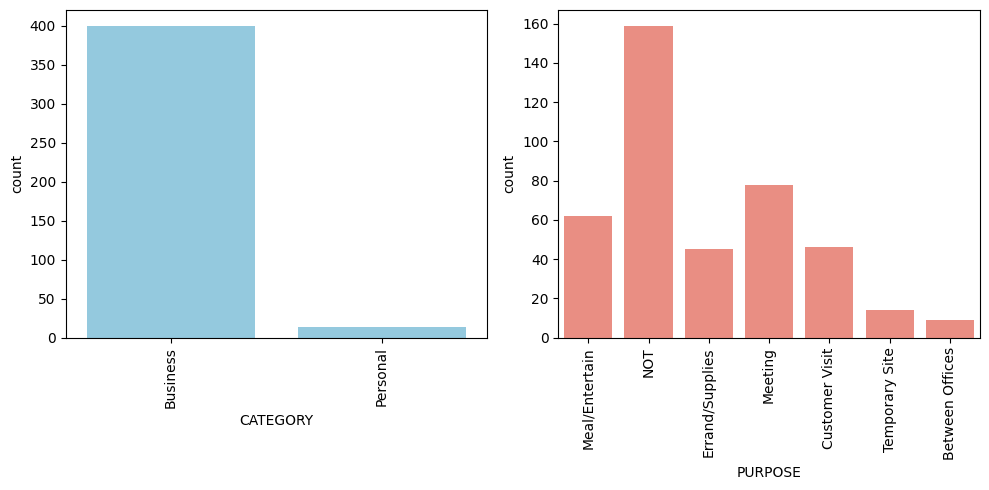

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_counts(dataset, features, figsize=(10, 5)):
    num_plots = len(features)
    fig, axes = plt.subplots(1, num_plots, figsize=figsize)
    if num_plots == 1:
        axes = [axes]

    colors = ["skyblue", "salmon"]  
    for i, feature in enumerate(features):
        sns.countplot(x=feature, data=dataset, ax=axes[i], color=colors[i % len(colors)])
        axes[i].set_xticks(range(len(axes[i].get_xticklabels())))
        axes[i].set_xticklabels([tick.get_text() for tick in axes[i].get_xticklabels()], rotation=90)

    plt.tight_layout()
    plt.show()
plot_categorical_counts(dataset, ['CATEGORY', 'PURPOSE'])


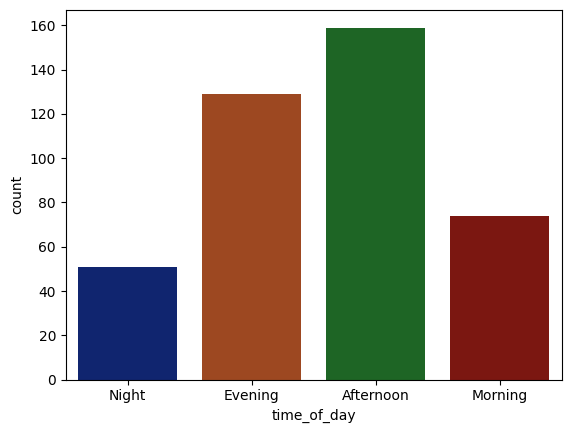

In [32]:
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], errors='coerce')
def classify_time_of_day(timestamp):
    if pd.notna(timestamp):
        hour = timestamp.hour
        if 6 <= hour < 12:
            return "Morning"
        elif 12 <= hour < 17:
            return "Afternoon"
        elif 17 <= hour < 21:
            return "Evening"
        else:
            return "Night"
    return None
dataset['time_of_day'] = dataset['START_DATE'].apply(classify_time_of_day)
dataset = dataset.dropna(subset=['time_of_day'])
sns.countplot(data=dataset, x='time_of_day', hue='time_of_day', palette='dark', legend=False)
plt.xticks(rotation=0)
plt.show()


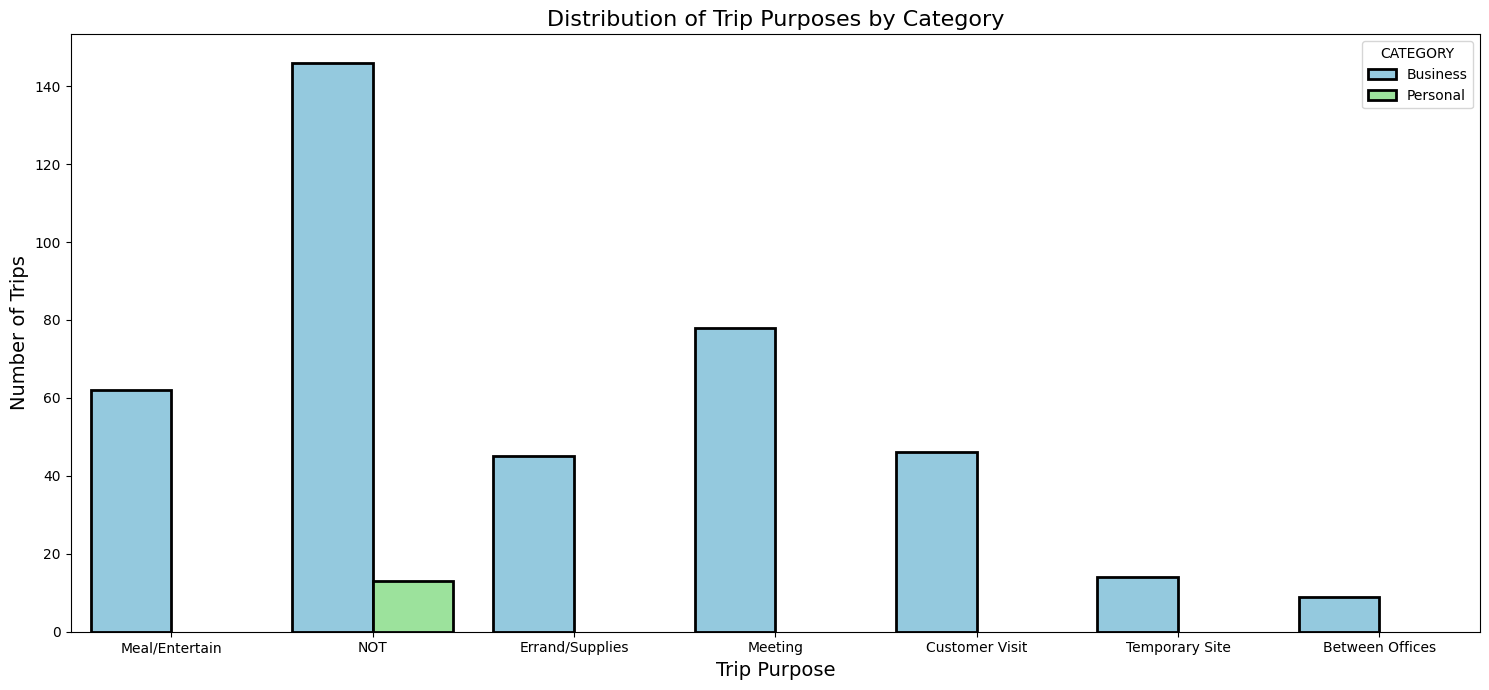

In [33]:
category_colors = {"Business": "skyblue", "Leisure": "salmon", "Personal": "lightgreen"}
plt.figure(figsize=(15, 7))
sns.countplot(
    data=dataset,
    x="PURPOSE",
    hue="CATEGORY",
    palette=category_colors,  
    linewidth=2,  
    edgecolor="black",  
)
plt.xticks(rotation=0)
plt.title("Distribution of Trip Purposes by Category", fontsize=16)
plt.xlabel("Trip Purpose", fontsize=14)
plt.ylabel("Number of Trips", fontsize=14)
plt.tight_layout()
plt.show()

<Axes: >

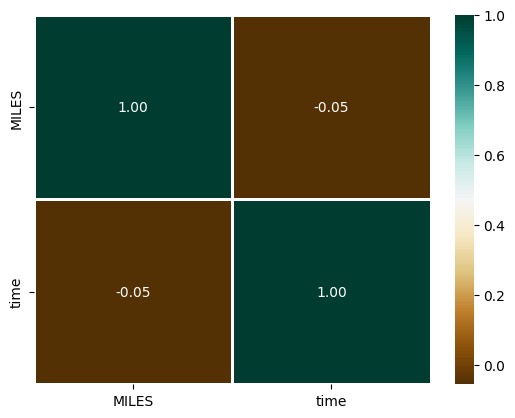

In [34]:
numeric_dataset = dataset.select_dtypes(include=['number'])
sns.heatmap(numeric_dataset.corr(),cmap='BrBG',fmt='.2f',linewidths=2,annot=True)


[Text(0.5, 0, 'MONTHS'), Text(0, 0.5, 'VALUE COUNT')]

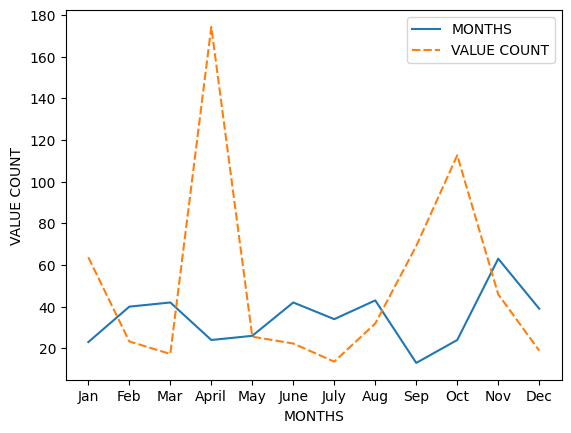

In [35]:
dataset['MONTH'] = pd.DatetimeIndex(dataset['START_DATE']).month
month_label = {1.0: 'Jan', 2.0: 'Feb', 3.0: 'Mar', 4.0: 'April',5.0: 'May', 6.0: 'June', 7.0: 'July', 8.0: 'Aug',9.0: 'Sep', 10.0: 'Oct', 11.0: 'Nov', 12.0: 'Dec'}
dataset["MONTH"] = dataset.MONTH.map(month_label)
mon = dataset.MONTH.value_counts(sort=False)
df = pd.DataFrame({"MONTHS": mon.values,"VALUE COUNT": dataset.groupby('MONTH',sort=False)['MILES'].max()})
p = sns.lineplot(data=df)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")

In [36]:
dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}
dataset['DAY'] = dataset['DAY'].map(day_label)


Text(0, 0.5, 'COUNT')

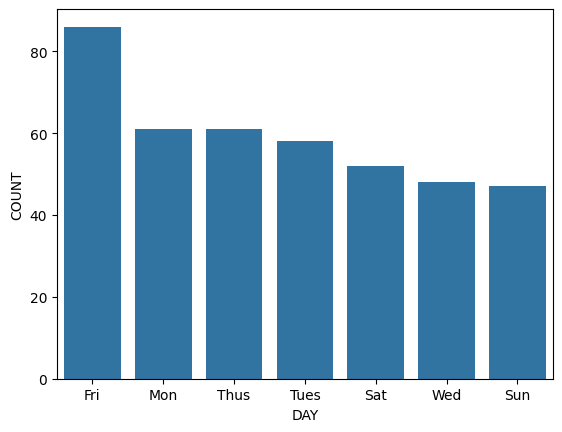

In [37]:
day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label);
plt.xlabel('DAY')
plt.ylabel('COUNT')


<Axes: ylabel='MILES'>

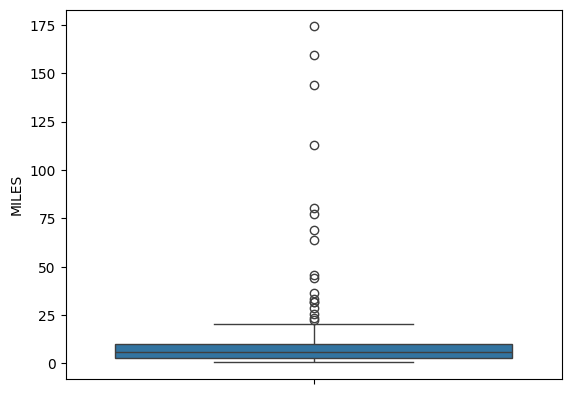

In [38]:
sns.boxplot(dataset['MILES'])

<Axes: ylabel='MILES'>

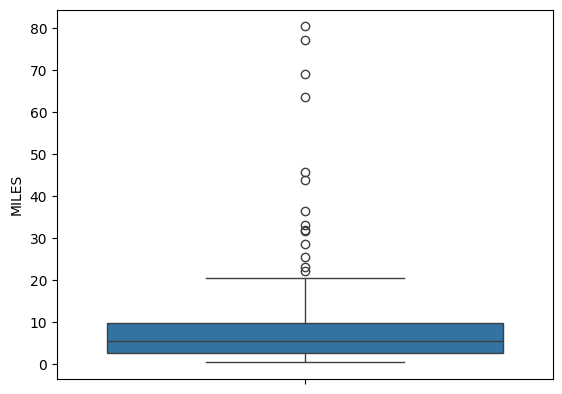

In [39]:
sns.boxplot(dataset[dataset['MILES']<100]['MILES'])

<Axes: xlabel='MILES', ylabel='Count'>

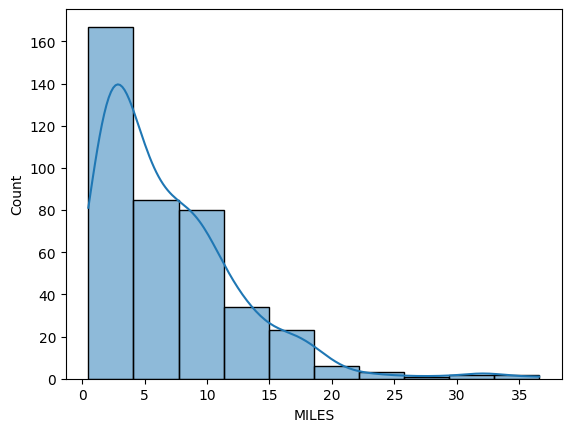

In [40]:
sns.histplot(dataset[dataset['MILES']<40]['MILES'],kde='True',bins=10)